# LowResPT — Redshift: Zero-shot & Fine-tune Evaluation

A **single shared group-aware 50/50 split** of the filtered spectra, used by both probes
below, so they evaluate on the *same* val samples and are directly comparable.

| Section | Probe | Encoder | Representation |
|---------|-------|---------|----------------|
| A  | Zero-shot k-NN (retrieval) | frozen      | **concat** patch tokens (fixed) |
| D1 | Fine-tune + linear head    | **unfrozen**| `POOL` |
| D2 | Fine-tune + 2-layer MLP head | **unfrozen**| `POOL` |

Zero-shot always uses concatenated patch tokens; the fine-tune section re-encodes the raw
spectra end-to-end and pools according to `POOL`.

In [ ]:
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

from model.low_res_pt import LowResPT
from data.dataset import LowResDataset
from data.datamodule import LowResDataModule

# == Config ====================================================================
CKPT = "/home/yacheng/ssl_outthere/encoder_spectrum/LowResPT/outputs/low_res_pt/version_2/checkpoints/epoch=epoch=333-val_hid_loss=val_hid_loss=0.1366.ckpt"
FITS = "/home/yacheng/ssl_outthere/images/DJA/DJA_spectra_v4.5.fits"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Sample filters (applied when building the dataset)
MIN_SN50     = 1          # min median S/N; None = no cut
MIN_REDSHIFT = 1        # keep z >  MIN_REDSHIFT
MAX_REDSHIFT = 3        # keep z <= MAX_REDSHIFT

# Representation
POOL = "meanmax"           # "concat" | "mean" | "max" | "meanmax" (mean+max, 2*D)

# Shared split + probes
SPLIT_FRAC = 0.5         # 50/50 train/val
KNN_K      = 5           # zero-shot k-NN neighbors
FS_STEPS   = 500          # few-shot gradient steps (mini-batches, not epochs)
FS_LR      = 1e-3
FS_WD      = 1e-4
ENC_LR     = 1e-4        # few-shot encoder fine-tuning learning rate
BATCH_SIZE = 64           # mini-batch size for every gradient-trained probe (B/C/D)
SEED       = 42
print(f"device={DEVICE}  pool={POOL}  z in ({MIN_REDSHIFT}, {MAX_REDSHIFT}]  "
      f"min_sn50={MIN_SN50}  batch_size={BATCH_SIZE}")

device=cuda  pool=meanmax  z in (1, 3]  min_sn50=1  batch_size=64


## Load frozen encoder

In [56]:
model = LowResPT.load_from_checkpoint(CKPT, map_location=DEVICE).eval().to(DEVICE)
print(f"loaded: embed_dim={model.embed_dim}  patch={model.hparams.patch_size}  stride={model.hparams.stride}")

loaded: embed_dim=128  patch=3  stride=2


## Helpers — embeddings, metrics, probes

In [57]:
def metrics(y, yp):
    # standard photo-z metrics on dz/(1+z)
    dz = (yp - y) / (1.0 + y)
    return dict(
        r2    = r2_score(y, yp),
        mae   = mean_absolute_error(y, yp),
        rmse  = float(np.sqrt(np.mean((y - yp) ** 2))),
        snmad = 1.4826 * np.median(np.abs(dz - np.median(dz))),
        out   = float(np.mean(np.abs(dz) > 0.15)),
    )

def show(tag, m):
    print(f"{tag:26s} R2={m['r2']:.3f}  MAE={m['mae']:.3f}  RMSE={m['rmse']:.3f}  "
          f"sNMAD={m['snmad']:.4f}  out={m['out']:.1%}")

@torch.no_grad()
def compute_embeddings(dataset, pool="concat", batch_size=256):
    # Frozen-encoder embedding for every spectrum, plus its redshift label.
    # Used here for ZERO-SHOT only, with pool="concat" (all N patch tokens
    # flattened, position preserved -> N*D). The fine-tune section does its own
    # pooling (POOL) on a trainable encoder, so it does not use this function.
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, collate_fn=LowResDataModule._pad_collate)
    Xs, ys = [], []
    for batch in loader:
        flux  = batch["flux"].to(DEVICE)
        wave  = batch["wavelength"].to(DEVICE)
        vmask = batch["valid_mask"].to(DEVICE)
        fn, mean, std = model._normalize_flux(flux, vmask, model.hparams.min_std)
        stats = torch.cat([mean, std], dim=-1)
        patches, wt, vp, tvm, _ = model._patchify(fn, wave, vmask)
        ps = model._compute_patch_stats(patches, vp)
        x  = model.encode(patches, wt, tvm, stats, patch_stats=ps)
        raw  = x[:, 1:, :]                                   # (B,N,D) patch tokens
        vm3  = tvm.float().unsqueeze(-1)                     # (B,N,1)
        tok  = raw * vm3                                     # invalid zeroed
        mean_ = tok.sum(1) / vm3.sum(1).clamp(min=1)         # (B,D)
        max_  = raw.masked_fill(tvm.unsqueeze(-1) == 0, float("-inf")).max(1).values
        max_  = torch.nan_to_num(max_, neginf=0.0)          # all-invalid row -> 0
        if pool == "concat":
            emb = tok.reshape(tok.shape[0], -1)
        elif pool == "mean":
            emb = mean_
        elif pool == "max":
            emb = max_
        elif pool == "meanmax":
            emb = torch.cat([mean_, max_], dim=-1)          # (B, 2*D)
        else:
            raise ValueError(pool)
        Xs.append(emb.cpu().numpy())
        ys.append(batch["redshift"].numpy())
    return np.concatenate(Xs), np.concatenate(ys)

def knn_zeroshot(X_tr, y_tr, X_va, k=KNN_K):
    # No parameters trained: standardize on the reference bank, distance-weighted k-NN.
    sc = StandardScaler().fit(X_tr)
    knn = KNeighborsRegressor(n_neighbors=k, weights="distance")
    knn.fit(sc.transform(X_tr), y_tr)
    return knn.predict(sc.transform(X_va))

def plot_pred(ax, y, yp, title, color):
    m = metrics(y, yp)
    lo, hi = MIN_REDSHIFT, MAX_REDSHIFT
    ax.scatter(y, yp, s=5, alpha=0.2, color=color, rasterized=True)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1",alpha=0.3)
    zl = np.linspace(lo, hi, 100)
    ax.fill_between(zl, zl - 0.15*(1+zl), zl + 0.15*(1+zl), alpha=0.10,
                    color="gray", label="+/-0.15*(1+z)")
    ax.set_xlabel("z_true"); ax.set_ylabel("z_pred")
    ax.set_title(f"{title}\nR2={m['r2']:.3f}  sNMAD={m['snmad']:.4f}  out={m['out']:.1%}",
                 fontsize=11)
    ax.set_xlim(lo-0.2, hi+0.2); ax.set_ylim(lo-0.2, hi+0.2)
    ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
    return m

## Dataset, embeddings, and the shared 50/50 split

In [58]:
ds = LowResDataset(FITS, min_sn50=MIN_SN50, min_redshift=MIN_REDSHIFT, max_redshift=MAX_REDSHIFT)
# Zero-shot embeddings: ALWAYS concat patch tokens (independent of POOL, which only
# controls the fine-tune pooling). X is used by the kNN zero-shot probe and to build
# the shared split; the fine-tune section re-encodes raw spectra itself.
X, y = compute_embeddings(ds, pool="concat")
print(f"zero-shot embeddings: X={X.shape}  pool=concat   z in [{y.min():.2f}, {y.max():.2f}]")

# Shared split used by zero-shot AND fine-tune -- GROUP-AWARE by objid so every
# spectrum of a given object lands entirely in train OR val. Removes the leakage
# where kNN could retrieve a same-object twin from the other half (the random split
# let ~10% of objids straddle train/val).
from sklearn.model_selection import GroupShuffleSplit
obj = ds.objid                                     # objid per row (dataset order)

gss = GroupShuffleSplit(n_splits=1, train_size=SPLIT_FRAC, random_state=SEED)
tr, va = next(gss.split(X, y, groups=obj))
X_tr, X_va, y_tr, y_va = X[tr], X[va], y[tr], y[va]
n_overlap = len(set(obj[tr]) & set(obj[va]))
print(f"group split by objid: train={len(tr)}  val={len(va)}  objid overlap={n_overlap}")
assert n_overlap == 0, "objid leaked across split"


Converting flux from f_nu (uJy) to f_lambda (∝ f_nu / λ²) (use_jansky=True to disable this conversion)
sn50 filtering: 18351/24121 samples with sn50 >= 1
redshift filtering: 14514/24121 samples with z > 1
redshift filtering: 8370/24121 samples with z <= 3
zero-shot embeddings: X=(8370, 3456)  pool=concat   z in [1.00, 3.00]
group split by objid: train=4167  val=4203  objid overlap=0


## Section A — Zero-shot (k-NN, no training)

Reference bank = the 50% train half; query = the 50% val half. Zero parameters trained.

== zero-shot k-NN (reference bank = 50% train half) ==
kNN k=1                    R2=0.863  MAE=0.063  RMSE=0.199  sNMAD=0.0064  out=4.8%
kNN k=5                    R2=0.887  MAE=0.069  RMSE=0.181  sNMAD=0.0055  out=4.9%
kNN k=10                   R2=0.882  MAE=0.077  RMSE=0.185  sNMAD=0.0059  out=5.4%
kNN k=20                   R2=0.861  MAE=0.090  RMSE=0.201  sNMAD=0.0074  out=6.4%


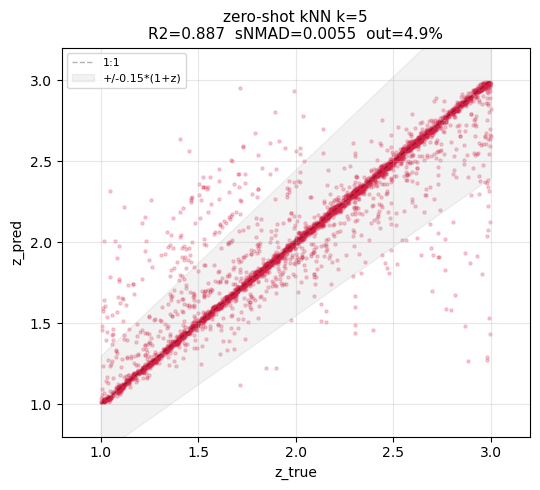

In [59]:
print("== zero-shot k-NN (reference bank = 50% train half) ==")
for k in (1, 5, 10, 20):
    show(f"kNN k={k}", metrics(y_va, knn_zeroshot(X_tr, y_tr, X_va, k)))
pred_zs = knn_zeroshot(X_tr, y_tr, X_va, KNN_K)

fig, ax = plt.subplots(figsize=(5.5, 5))
plot_pred(ax, y_va, pred_zs, f"zero-shot kNN k={KNN_K}", "crimson")
plt.tight_layout(); plt.show()

# Section D — Fine-tune (encoder unfrozen)

We **unfreeze the LowResPT encoder** and train it end-to-end with the head, so the
representation itself can adapt to redshift. Pooling follows `POOL`.

Same group-aware 50/50 split (`tr`/`va`) as the zero-shot probe, mini-batch SGD
(`BATCH_SIZE`) for `FS_STEPS` steps, head `lr`/`wd`/`SEED` from config. The backbone
uses a gentler `ENC_LR` so a 128-d encoder isn't blown up by `FS_LR` in a few steps.

| Probe | Head | Encoder |
|-------|------|---------|
| D1 | linear      | fine-tuned |
| D2 | 2-layer MLP | fine-tuned |

Each run reloads a **fresh** copy of the checkpoint, so the frozen `model` used for
zero-shot is untouched and the two runs don't share weights. The encoder ends in a
`final_ln` (LayerNorm), so token features are already ~unit-scale — we skip any fixed
feature scaler and only standardize the target `z` (the feature distribution shifts
every step as the encoder trains).

In [60]:
# Fine-tune helpers (reuses the SAME split tr/va as zero-shot; pooling = POOL)
from torch.utils.data import Subset
from tqdm.auto import tqdm

def encode_pooled(enc, batch, pool=POOL):
    # Embedding pipeline on a TRAINABLE encoder (no torch.no_grad, so gradients flow
    # back into enc). Pools per the POOL config -- this is the only place POOL is used.
    flux  = batch["flux"]; wave = batch["wavelength"]; vmask = batch["valid_mask"]
    fn, mean, std = enc._normalize_flux(flux, vmask, enc.hparams.min_std)
    stats = torch.cat([mean, std], dim=-1)
    patches, wt, vp, tvm, _ = enc._patchify(fn, wave, vmask)
    ps = enc._compute_patch_stats(patches, vp)
    x  = enc.encode(patches, wt, tvm, stats, patch_stats=ps)
    raw  = x[:, 1:, :]                                   # (B,N,D) patch tokens
    vm3  = tvm.float().unsqueeze(-1)
    tok  = raw * vm3
    mean_ = tok.sum(1) / vm3.sum(1).clamp(min=1)
    max_  = raw.masked_fill(tvm.unsqueeze(-1) == 0, float("-inf")).max(1).values
    max_  = torch.nan_to_num(max_, neginf=0.0)
    if pool == "concat":  return tok.reshape(tok.shape[0], -1)
    if pool == "mean":    return mean_
    if pool == "max":     return max_
    if pool == "meanmax": return torch.cat([mean_, max_], dim=-1)
    raise ValueError(pool)

def finetune(head_kind="linear", hidden=256, dropout=0.1, steps=FS_STEPS,
             head_lr=FS_LR, enc_lr=ENC_LR, wd=FS_WD, bs=BATCH_SIZE):
    # End-to-end fine-tune of a FRESH encoder copy + a head, mini-batch SGD (bs=
    # BATCH_SIZE), same split (tr/va) / steps / wd / seed. Pooling = POOL. Target
    # standardized on the train half (features come from the encoder's final
    # LayerNorm). Backbone gets a gentler enc_lr than the head.
    enc = LowResPT.load_from_checkpoint(CKPT, map_location=DEVICE).to(DEVICE)

    train_loader = DataLoader(Subset(ds, [int(i) for i in tr]), batch_size=bs,
                              shuffle=True, num_workers=0, drop_last=False,
                              collate_fn=LowResDataModule._pad_collate)
    val_loader   = DataLoader(Subset(ds, [int(i) for i in va]), batch_size=256,
                              shuffle=False, num_workers=0,
                              collate_fn=LowResDataModule._pad_collate)

    # Head input dim follows POOL (mean->D, meanmax->2D, concat->N*D); derive from a batch.
    enc.eval()
    with torch.no_grad():
        probe = {k: v.to(DEVICE) for k, v in next(iter(val_loader)).items()}
        in_dim = encode_pooled(enc, probe).shape[1]

    torch.manual_seed(SEED)
    if head_kind == "linear":
        head = nn.Linear(in_dim, 1).to(DEVICE)
    elif head_kind == "mlp":
        head = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                             nn.Dropout(dropout), nn.Linear(hidden, 1)).to(DEVICE)
    else:
        raise ValueError(head_kind)

    ysc = StandardScaler().fit(y_tr.reshape(-1, 1))
    y_mean, y_std = float(ysc.mean_[0]), float(ysc.scale_[0])   # standardize z on the fly
    opt = torch.optim.Adam(
        [{"params": enc.parameters(),  "lr": enc_lr},
         {"params": head.parameters(), "lr": head_lr}], weight_decay=wd)

    enc.train(); head.train()
    step = 0
    pbar = tqdm(total=steps, desc=f"Fine-tuning ({head_kind})")
    while step < steps:
        for batch in train_loader:
            if step >= steps:
                break
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            yb = (batch["redshift"].float().unsqueeze(1) - y_mean) / y_std
            opt.zero_grad()
            loss = nn.functional.mse_loss(head(encode_pooled(enc, batch)), yb)
            loss.backward(); opt.step()
            step += 1; pbar.update(1)
    pbar.close()

    enc.eval(); head.eval()
    preds = []
    with torch.no_grad():
        for batch in val_loader:                         # val in order -> matches y_va
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            preds.append(head(encode_pooled(enc, batch)).cpu().numpy())
    pred = ysc.inverse_transform(np.concatenate(preds)).squeeze(1)   # back to physical z
    return pred, float(loss.item())


## D1 — Fine-tuned encoder + linear head

A single linear head on top of the unfrozen encoder (backbone lr `ENC_LR`), pooling = `POOL`.

Fine-tuning (linear):   0%|          | 0/500 [00:00<?, ?it/s]

fine-tuned linear: 500 steps  enc_lr=0.0001  final train MSE=0.0355
fine-tuned linear          R2=0.930  MAE=0.090  RMSE=0.142  sNMAD=0.0218  out=1.9%


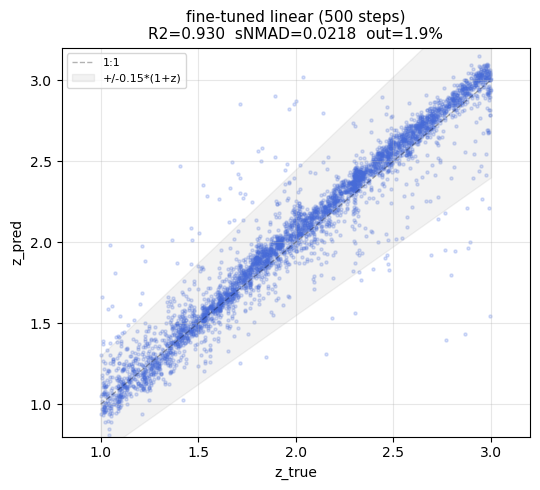

In [61]:
pred_ft_lin, ft_lin_mse = finetune("linear")
print(f"fine-tuned linear: {FS_STEPS} steps  enc_lr={ENC_LR}  final train MSE={ft_lin_mse:.4f}")
show("fine-tuned linear", metrics(y_va, pred_ft_lin))

fig, ax = plt.subplots(figsize=(5.5, 5))
plot_pred(ax, y_va, pred_ft_lin, f"fine-tuned linear ({FS_STEPS} steps)", "royalblue")
plt.tight_layout(); plt.show()

## D2 — Fine-tuned encoder + 2-layer MLP head

Same as D1 but with a 2-layer MLP head (`Linear -> ReLU -> Dropout -> Linear`), pooling = `POOL`.

Fine-tuning (mlp):   0%|          | 0/500 [00:00<?, ?it/s]

fine-tuned MLP (2-layer, hidden=256): 500 steps  enc_lr=0.0001  final train MSE=0.0205
fine-tuned MLP (2-layer)   R2=0.937  MAE=0.069  RMSE=0.136  sNMAD=0.0172  out=2.0%


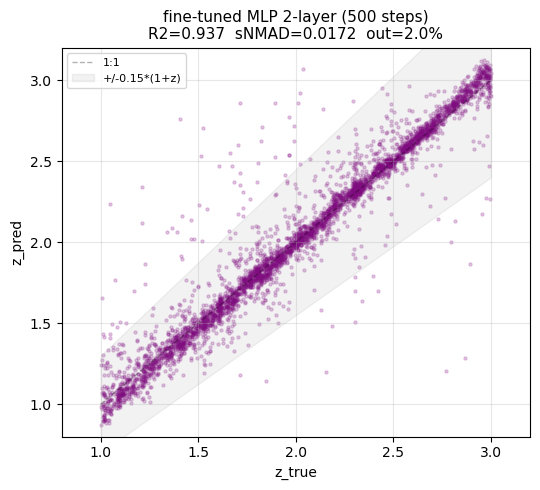

In [62]:
pred_ft_mlp, ft_mlp_mse = finetune("mlp", hidden=256, dropout=0.1)
print(f"fine-tuned MLP (2-layer, hidden=256): {FS_STEPS} steps  enc_lr={ENC_LR}  final train MSE={ft_mlp_mse:.4f}")
show("fine-tuned MLP (2-layer)", metrics(y_va, pred_ft_mlp))

fig, ax = plt.subplots(figsize=(5.5, 5))
plot_pred(ax, y_va, pred_ft_mlp, f"fine-tuned MLP 2-layer ({FS_STEPS} steps)", "purple")
plt.tight_layout(); plt.show()

## Summary — zero-shot vs fine-tuned (same val split)

Zero-shot kNN (frozen, concat) vs the two fine-tuned heads (D1, D2), all on the
identical 50% val half.

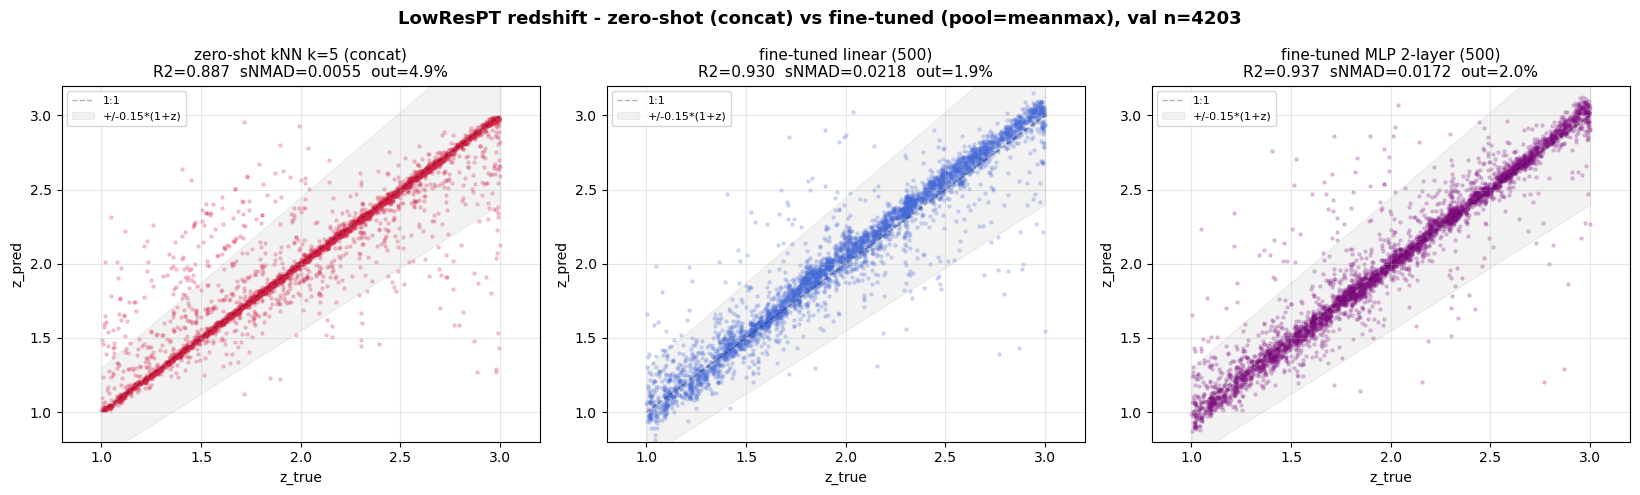

SUMMARY   val n=4203   z in (1,3]
          zero-shot pool=concat   fine-tune pool=meanmax
          FS_STEPS=500  head_lr=0.001  enc_lr=0.0001  wd=0.0001
zero-shot kNN (concat)     R2=0.887  MAE=0.069  RMSE=0.181  sNMAD=0.0055  out=4.9%
fine-tuned linear          R2=0.930  MAE=0.090  RMSE=0.142  sNMAD=0.0218  out=1.9%
fine-tuned MLP 2-layer     R2=0.937  MAE=0.069  RMSE=0.136  sNMAD=0.0172  out=2.0%


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
m_zs    = plot_pred(axes[0], y_va, pred_zs,     f"zero-shot kNN k={KNN_K} (concat)",      "crimson")
m_ft_l  = plot_pred(axes[1], y_va, pred_ft_lin, f"fine-tuned linear ({FS_STEPS})",        "royalblue")
m_ft_m  = plot_pred(axes[2], y_va, pred_ft_mlp, f"fine-tuned MLP 2-layer ({FS_STEPS})",   "purple")
plt.suptitle(f"LowResPT redshift - zero-shot (concat) vs fine-tuned (pool={POOL}), val n={len(y_va)}",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("="*62)
print(f"SUMMARY   val n={len(y_va)}   z in ({MIN_REDSHIFT},{MAX_REDSHIFT}]")
print(f"          zero-shot pool=concat   fine-tune pool={POOL}")
print(f"          FS_STEPS={FS_STEPS}  head_lr={FS_LR}  enc_lr={ENC_LR}  wd={FS_WD}")
print("="*62)
show("zero-shot kNN (concat)", m_zs)
show("fine-tuned linear",      m_ft_l)
show("fine-tuned MLP 2-layer", m_ft_m)

# test to convert to f lambda